In [100]:
import numpy as np
import matplotlib.pyplot as plt
import math,copy

In [101]:
input_array = np.array([1,2,3])
exp_array = np.exp(input_array)
print(f"Input of exp: {input_array}")
print(f"Output of exp:{exp_array}")

Input of exp: [1 2 3]
Output of exp:[ 2.718  7.389 20.086]


In [102]:
def sigmoid(z):
    g = 1/(1+np.exp(-z))
    return g

In [103]:
z_tmp = np.arange(-10,11)
y=sigmoid(z_tmp)
np.set_printoptions(precision=3)
print("Input (z) Output (sigmoid(z))")
print(np.c_[z_tmp,y])

Input (z) Output (sigmoid(z))
[[-1.000e+01  4.540e-05]
 [-9.000e+00  1.234e-04]
 [-8.000e+00  3.354e-04]
 [-7.000e+00  9.111e-04]
 [-6.000e+00  2.473e-03]
 [-5.000e+00  6.693e-03]
 [-4.000e+00  1.799e-02]
 [-3.000e+00  4.743e-02]
 [-2.000e+00  1.192e-01]
 [-1.000e+00  2.689e-01]
 [ 0.000e+00  5.000e-01]
 [ 1.000e+00  7.311e-01]
 [ 2.000e+00  8.808e-01]
 [ 3.000e+00  9.526e-01]
 [ 4.000e+00  9.820e-01]
 [ 5.000e+00  9.933e-01]
 [ 6.000e+00  9.975e-01]
 [ 7.000e+00  9.991e-01]
 [ 8.000e+00  9.997e-01]
 [ 9.000e+00  9.999e-01]
 [ 1.000e+01  1.000e+00]]


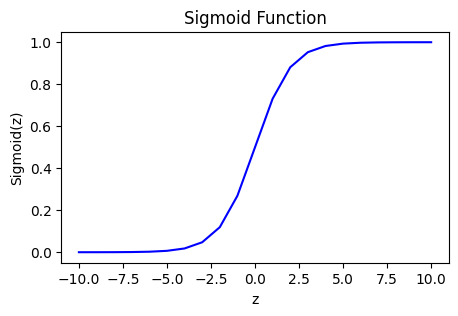

In [104]:
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(z_tmp,y,c="b")
ax.set_title("Sigmoid Function")
ax.set_ylabel('Sigmoid(z)')
ax.set_xlabel('z')
plt.show()

In [105]:
x_train = np.array([0.,1,2,3,4,5])
y_train = np.array([0,0,0,1,1,1])

w_in = np.zeros((1))
b_in = 0

In [106]:
def compute_cost(X,y,w,b):
    m=X.shape[0]
    cost=0.
    for i in range(m):
        z_i=np.dot(X[i],w)+b
        f_wb_i =sigmoid(z_i)
        cost+= -y[i] * np.log(f_wb_i) - (1-y[i]) * np.log(1-f_wb_i)
    cost/=m
    return cost

In [107]:
cost=compute_cost(x_train,y_train,w_in,b_in)
print(cost)

[0.693]


In [108]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

In [109]:
w_tmp=np.array([1,1])
b_tmp=-3
print(compute_cost(X_train,y_train,w_tmp,b_tmp))

0.36686678640551745


In [110]:
b_tmp=-4
print(compute_cost(X_train,y_train,w_tmp,b_tmp))

0.5036808636748461


In [111]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

In [112]:
def compute_gradient(X,y,w,b):
    m,n=X.shape
    dj_dw=np.zeros(n)
    dj_db=0.
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w)+b)
        err_i = f_wb_i-y[i]
        for j in range(n):
            dj_dw[j]+=(err_i)*X[i,j]
        dj_db+=err_i
    dj_dw/=m
    dj_db/=m
    return dj_dw,dj_db

In [113]:
w_tmp = np.array([2.,3.])
b_tmp = 1.
dj_dw_tmp,dj_db_tmp = compute_gradient(X_train,y_train,w_tmp,b_tmp)
print(f"dj_db: {dj_db_tmp}" )
print(f"dj_dw: {dj_dw_tmp.tolist()}" )

dj_db: 0.49861806546328574
dj_dw: [0.498333393278696, 0.49883942983996693]


In [114]:
def gradient_descent(X,y,w_in,b_in,alpha,num_iters):
    J_history = []
    w = copy.deepcopy(w_in)
    b= b_in
    for i in range(num_iters):
        dj_dw,dj_db = compute_gradient(X,y,w,b)
        w = w-alpha*dj_dw
        b = b-alpha*dj_db
        if i<10000:
            J_history.append(compute_cost(X,y,w,b))
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]}   ")
    return w,b,J_history

In [115]:
def run_gradient_descent(X,y,alpha,iterations):
    w_in = np.zeros_like(X[0])
    b_in = 0.
    return gradient_descent(X,y,w_in,b_in,alpha,iterations)

In [132]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])
w_out,b_out,hist = run_gradient_descent(X_train,y_train,1.5,10000)
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.6631848095557231   
Iteration 1000: Cost 0.011351105156177701   
Iteration 2000: Cost 0.005663491494226128   
Iteration 3000: Cost 0.0037726416678394194   
Iteration 4000: Cost 0.002828443375051764   
Iteration 5000: Cost 0.0022623349885141104   
Iteration 6000: Cost 0.0018850969624334233   
Iteration 7000: Cost 0.0016157189534774647   
Iteration 8000: Cost 0.0014137247810475286   
Iteration 9000: Cost 0.0012566393558498532   

updated parameters: w:[8.893 8.693], b:-24.177767018316988


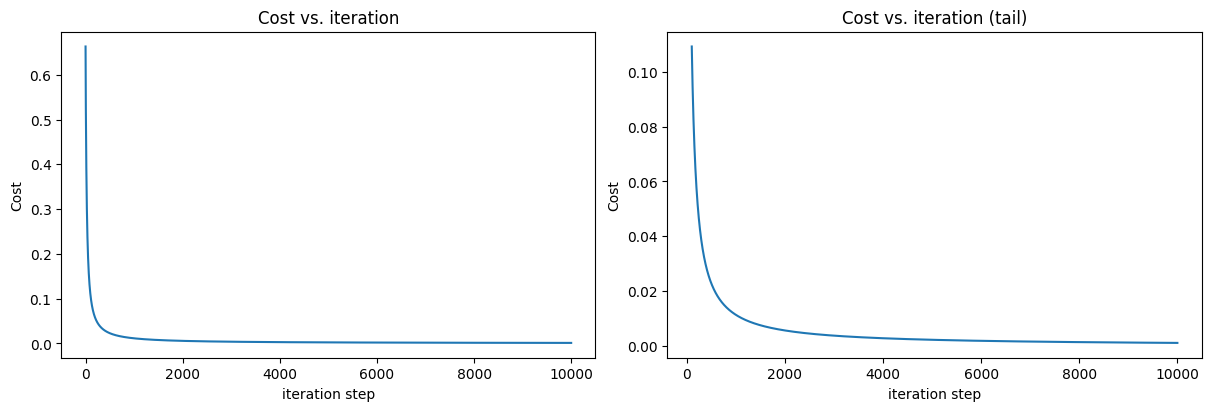

In [133]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(hist)
ax2.plot(100 + np.arange(len(hist[100:])), hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()